<a href="https://colab.research.google.com/github/Mariem-mcs/project-recommendation-engine/blob/main/13_hyperparameter_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.1 MB/s eta 0:00:00
Loading MovieLens dataset...
Data saved locally
DATA LOADED
Movies: 9,742
Ratings: 100,836
Users: 610
Data ready for training
HYPERPARAMETER EXPERIMENT

Testing combinations...
Testing n_factors=10, n_epochs=5... RMSE=0.8940
Testing n_factors=10, n_epochs=10... RMSE=0.8835
Testing n_factors=10, n_epochs=20... RMSE=0.8759
Testing n_factors=10, n_epochs=50... RMSE=0.8797
Testing n_factors=20, n_epochs=5... RMSE=0.8948
Testing n_factors=20, n_epochs=10... RMSE=0.8845
Testing n_factors=20, n_epochs=20... RMSE=0.8780
Testing n_factors=20, n_epochs=50... RMSE=0.8932
Testing n_factors=50, n_epochs=5... RMSE=0.8960
Testing n_factors=50, n_epochs=10... RMSE=0.8852
Testing n_factors=50, n_epochs=20... RMSE=0.8775
Testing n_factors=50, n_epochs=50... RMSE=0.8942
Testing n_factors=100, n_epochs=5... RMSE=0.8979
Testing n_factors=100, n_epochs=10... RMSE=0.8874
Testing n_factors=100, n_epochs=20... RMSE=0.8807
Testing n_fa

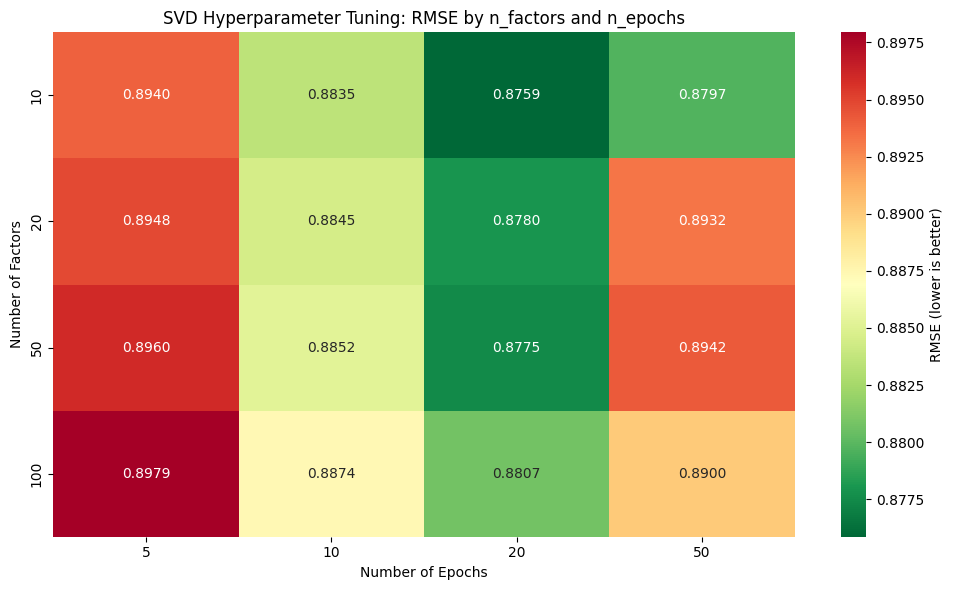

Heatmap saved as hyperparameter_heatmap.png
RECOMMENDATION
Best parameters for SVD:
  n_factors = 10.0
  n_epochs = 20.0
  Expected RMSE: 0.8759
TODO 11 Complete!


In [1]:
# TODO 11: HYPERPARAMETER EXPERIMENT
!pip install scikit-surprise -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile, requests
from io import BytesIO
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as surprise_train_test_split

# 1. Loading the data:
print("Loading MovieLens dataset...")
try:
    movies_df = pd.read_csv('movies.csv')
    ratings_df = pd.read_csv('ratings.csv')
    print("Data loaded from local files")
except FileNotFoundError:
    print("Downloading dataset from GroupLens...")
    url = "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    response = requests.get(url)
    zip_file = zipfile.ZipFile(BytesIO(response.content))
    movies_df = pd.read_csv(zip_file.open('ml-latest-small/movies.csv'))
    ratings_df = pd.read_csv(zip_file.open('ml-latest-small/ratings.csv'))
    movies_df.to_csv('movies.csv', index=False)
    ratings_df.to_csv('ratings.csv', index=False)
    print("Data saved locally")
df = pd.merge(ratings_df, movies_df, on='movieId')
print("DATA LOADED")
print(f"Movies: {movies_df.shape[0]:,}")
print(f"Ratings: {ratings_df.shape[0]:,}")
print(f"Users: {ratings_df['userId'].nunique():,}")

#2. Preparing the data:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)
print("Data ready for training")

# 3. Hyperparameter experiment:
print("HYPERPARAMETER EXPERIMENT")
# Parameters to test:
n_factors_values = [10, 20, 50, 100]
n_epochs_values = [5, 10, 20, 50]
results = []
print("\nTesting combinations...")
for n_factors in n_factors_values:
    for n_epochs in n_epochs_values:
        print(f"Testing n_factors={n_factors}, n_epochs={n_epochs}...", end=" ")

        # Train model:
        model = SVD(
            n_factors=n_factors,
            n_epochs=n_epochs,
            lr_all=0.005,
            reg_all=0.02,
            random_state=42
        )
        model.fit(trainset)

        # Evaluation on the test set:
        preds = model.test(testset)
        rmse = np.sqrt(np.mean([(p.est - p.r_ui)**2 for p in preds]))

        results.append({
            'n_factors': n_factors,
            'n_epochs': n_epochs,
            'rmse': rmse
        })
        print(f"RMSE={rmse:.4f}")

# 4. The results table:
print("\n" + "="*60)
print("RESULTS TABLE")
print("="*60)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Finding the best combination:
best = results_df.loc[results_df['rmse'].idxmin()]
print("BEST COMBINATION")
print(f"Best RMSE: {best['rmse']:.4f}")
print(f"Best n_factors: {best['n_factors']}")
print(f"Best n_epochs: {best['n_epochs']}")

# 5. Heatmap visualization:
print("HEATMAP VISUALIZATION")
# Creating the pivot table for heatmap:
pivot_table = results_df.pivot(index='n_factors', columns='n_epochs', values='rmse')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='RdYlGn_r',
            cbar_kws={'label': 'RMSE (lower is better)'})
plt.title('SVD Hyperparameter Tuning: RMSE by n_factors and n_epochs')
plt.xlabel('Number of Epochs')
plt.ylabel('Number of Factors')
plt.tight_layout()
plt.savefig('hyperparameter_heatmap.png')
plt.show()
print("Heatmap saved as hyperparameter_heatmap.png")

#6. Recommandation:
print("RECOMMENDATION")
print(f"Best parameters for SVD:")
print(f"  n_factors = {best['n_factors']}")
print(f"  n_epochs = {best['n_epochs']}")
print(f"  Expected RMSE: {best['rmse']:.4f}")

print("TODO 11 Complete!")